In [1]:
# Symbol and config name
SYMBOL = 'ETHUSDC'
CONF = 'list_1u'

In [2]:
# Global filters
ONLY_SIDE = 0 # -1 = short, 0 = no filter, 1 = long
TEST_VOLUME_FROM = 0
TEST_VOLUME_TO = 500_000 + 1

In [3]:
# Load tests from results folder
import pickle, os
from tqdm import tqdm

def load_tests(symbol, conf):
    folder = f'/_data/base/{symbol}/results/{conf}'
    assert os.path.isdir(folder), f'Results folder not found: {folder}'

    files = [fn for fn in os.listdir(folder) if fn.endswith('.pkl')]
    files.sort()
    assert len(files) > 0, f'No result files in: {folder}'

    sizes_mb = 0.0
    count = 0

    test_data: list = []
    pbar = tqdm(total=len(files), desc=f'Loading tests for {symbol} {conf}')

    for fn in files:
        pbar.update(1)
        path = f'{folder}/{fn}'
        assert os.path.isfile(path), f'Not a file: {path}'
        size_mb = os.path.getsize(path) / 1024 / 1024
        with open(path, 'rb') as f:
            data = pickle.load(f)
        assert isinstance(data, list), f'File is not a list: {path}'
        test_data.extend(data)
        sizes_mb += size_mb
        count += len(data)
    
    pbar.close()

    print(f'Total size: {sizes_mb:.3f} MB')
    print(f'Loaded total: {len(test_data)} tests from {len(files)} files')

    return test_data

In [4]:
# Load tests
test_data = load_tests(SYMBOL, CONF)

Loading tests for ETHUSDC list_1u: 100%|██████████| 100/100 [00:16<00:00,  5.93it/s]

Total size: 828.816 MB
Loaded total: 989106 tests from 100 files


In [5]:
# Leverage
import numpy as np, math
from scipy.stats import gaussian_kde
from scipy.signal import fftconvolve

def leverage_report_gather_params(test_data):
    """
    Концепция расчета плеча:

    Ввиду того, что логика стоповая (позиция всегда стремится быть в направлении цены), 
    пиковая загрузка маржи всегда возникает рядом с триггером. Разберем подробнее:

    - Стартовая точка: загрузка маржи = M, PnL = 0
    - При движении далее к таргету: маржа остается константной, PnL > 0 и покрывает ее часть
    - При движении обратно к триггеру: обратная ситуация
    - При касании триггера: начинается чейз, возникает проскальзывание, PnL < 0, что 
    добавляет нагрузки на маржу

    Соответственно, в идеальной ситуации плечо для такой операции должно быть 1 к 
    бесконечности, так как, по определению плеча:

    - Биржа выдает кредит, умножая лот на некоторое значение L
    - Вместо максимальной просадки 1 теперь можно позволить себе только 1/L
    - Также есть тонкая прослойка в виде "безопасной зоны" для ликвидации со стороны 
    биржи, которую мы далее учитывать не будем пока

    Согласно приведенному алгоритму, размер маржи M есть наихудший случай.

    От идеальной нашу ситуацию отличает как раз наличие проскальзывания при сбросе 
    позиции по возврату к триггеру, а также наличие PnL после нее. Сооответственно, мы 
    вводим 3 случайных величины (функции) на базе бэктеста:

    - R(sigma): отрицательный PnL по результату позиции в процентах от лота 
      (положительный не берем пока)
    - D(sigma): длительность позиции, выраженнная в количестве позиций в неделю
    - S(sigma): проскальзывание, выраженное в процентах от цены триггера
   
    Далее можно выразить требуемую маржу:

    При плече L маржа на 1 лот составляет: M = 1/L
    При добавлении просадки S и PnL R наша итоговая формула для 1 лота и одного 
    эпизода (одной позиции):

    M = 1/L + (S + R)/100

    Далее составим функцию вероятности ликвидации за неделю через последовательность 
    независимых экспериментов:

    Событие ликвидации наступает при условии S + R >= 100/L
    Обозначим противоположное условие как p = P(S + R < 100/L)

    Итого, наша формула вероятности ликвидации за неделю:
    Pw = 1 - p^D как функция от (S, L)
    """

    # Gather params
    pnl_list = []
    positions_per_week_list = []
    neutral_excursions_list = []

    for item in test_data:
        total_trades_executed = int(item['stat']['agg']['total_trades_executed'])
        if total_trades_executed == 0:
            continue

        test_volume_usd = float(item['run_conf']['test_volume_usd'])
        if test_volume_usd < TEST_VOLUME_FROM or test_volume_usd > TEST_VOLUME_TO:
            continue

        only_side = int(item['run_conf']['only_side'])
        if only_side != ONLY_SIDE:
            continue

        sigma = float(item['v'])
        pnl = min(0, float(item['stat']['agg']['pnl']) / test_volume_usd * 100.0)
        positions_per_week = (7*24*60*60) / float(item['stat']['agg']['full_execution_time'])

        pnl_list.append((sigma, pnl))
        positions_per_week_list.append((sigma, positions_per_week))

        for ne in item['neutral_excursions']:
            neutral_excursions_list.append((sigma, ne))

    print(f'Gathered: {len(neutral_excursions_list)} neutral excursions and {len(pnl_list)} params')

    # Sort by sigma
    pnl_list.sort(key=lambda x: x[0])
    positions_per_week_list.sort(key=lambda x: x[0])
    neutral_excursions_list.sort(key=lambda x: x[0])

    return pnl_list, positions_per_week_list, neutral_excursions_list

class Functions:
    def __init__(self, pnl_list, positions_per_week_list, neutral_excursions_list, sigma_deviation=0.15, n_bins=1000, max_points=1000):
        # Set params
        self.sigma_deviation = sigma_deviation
        self.n_bins = n_bins
        self.max_points = max_points

        # Data to numpy
        self.pnl = np.array(pnl_list, dtype=np.float64)
        self.positions_per_week = np.array(positions_per_week_list, dtype=np.float64)
        self.neutral_excursions = np.array(neutral_excursions_list, dtype=np.float64)

        # Inverse neutral excursions
        self.neutral_excursions[:, 1] = - self.neutral_excursions[:, 1]
        
    def _get_part(self, array, sigma):
        # Slippage function
        from_sigma = sigma * (1 - self.sigma_deviation)
        to_sigma = sigma * (1 + self.sigma_deviation)

        # From and to indexes for neutral excursions
        from_index = np.searchsorted(array[:, 0], from_sigma)
        to_index = np.searchsorted(array[:, 0], to_sigma)

        # Get parts for neutral excursions
        part = array[from_index:to_index]

        return part

    def _get_pdf(self, values):
        # If there is almost no data, better not to invent anything
        assert values.size >= 5, f'Not enough data: {values.size}'

        # Limit the number of points
        if values.size > self.max_points:
            values = values[np.random.choice(values.size, self.max_points, replace=False)]

        # Linspace grid (uniform)
        x = np.linspace(values.min(), values.max(), self.n_bins)

        # KDE estimation
        kde = gaussian_kde(values)
        pdf = kde(x)

        # Normalize via integral
        area = np.trapz(pdf, x)
        if area > 0:
            pdf = pdf / area

        return x, pdf

    def get_sigma_pdf(self):
        return self._get_pdf(self.pnl[:, 0])

    def get_R(self, sigma):
        # Get parts
        part = self._get_part(self.pnl, sigma)
        return self._get_pdf(part[:, 1])

    def get_D(self, sigma):
        # Get parts
        part = self._get_part(self.positions_per_week, sigma)
        return self._get_pdf(part[:, 1])

    def get_S(self, sigma):
        # Get parts
        part = self._get_part(self.neutral_excursions, sigma)
        return self._get_pdf(part[:, 1])

    def _uniformize(self, x, p, dx):
        # Uniformize pdf on the same grid
        xi = np.arange(x.min(), x.max() + dx/2, dx)
        pi = np.interp(xi, x, p)
        pi = np.clip(pi, 0, None)
        area = np.trapz(pi, xi)
        if area > 0:
            pi = pi / area
        return xi, pi

    def _convolve_pdfs(self, x1, p1, x2, p2):
        dx1 = np.mean(np.diff(x1))
        dx2 = np.mean(np.diff(x2))
        dx = min(dx1, dx2)
        x1u, p1u = self._uniformize(x1, p1, dx)
        x2u, p2u = self._uniformize(x2, p2, dx)
        psum = fftconvolve(p1u, p2u, mode='full') * dx
        xsum = np.arange(x1u[0] + x2u[0], x1u[-1] + x2u[-1] + dx/2, dx)
        psum = np.clip(psum, 0, None)
        area = np.trapz(psum, xsum)
        if area > 0:
            psum = psum / area
        return xsum, psum

    def get_SR(self, sigma):
        xS, pS = self.get_S(sigma)
        xR, pR = self.get_R(sigma)
        return self._convolve_pdfs(xS, pS, xR, pR)

    def get_liquidation_probability(self, sigma, L):
        x, p = self.get_SR(sigma)
        z0 = - 100.0 / L
        mask = x <= z0
        if not np.any(mask):
            return 0.0
        return np.trapz(p[mask], x[mask])

    def get_week_pos_count_mode(self, sigma):
        x, pdf = self.get_D(sigma)
        return int(math.ceil(x[np.argmax(pdf)]))

    def get_realized_pnl_mode(self, sigma):
        x, pdf = self.get_R(sigma)
        return x[np.argmax(pdf)]

    def _cdf(self, x, p):
        c = np.zeros_like(p)
        if p.size > 1:
            dx = x[1:] - x[:-1]
            c[1:] = np.cumsum(0.5 * (p[1:] + p[:-1]) * dx)
        if c[-1] > 0:
            c = c / c[-1]
        return c

    def _get_guaranteed(self, x, pdf, P, tail='le'):
        cdf = self._cdf(x, pdf)

        P = float(np.clip(P, 0.0, 1.0))
        target = 1.0 - P if tail == 'ge' else P
        target = float(np.clip(target, 0.0, 1.0))
         
        return np.interp(target, cdf, x)

    def get_guaranteed_sigma(self, P, tail='le'):
        x, pdf = self.get_sigma_pdf()
        return self._get_guaranteed(x, pdf, P, tail)


In [6]:
# Gather params
pnl_list, positions_per_week_list, neutral_excursions_list = leverage_report_gather_params(test_data)

Gathered: 66615108 neutral excursions and 989106 params


In [7]:
# Functions
import matplotlib.pyplot as plt

# Initialize functions
func = Functions(pnl_list, positions_per_week_list, neutral_excursions_list)

<Figure size 640x480 with 0 Axes>

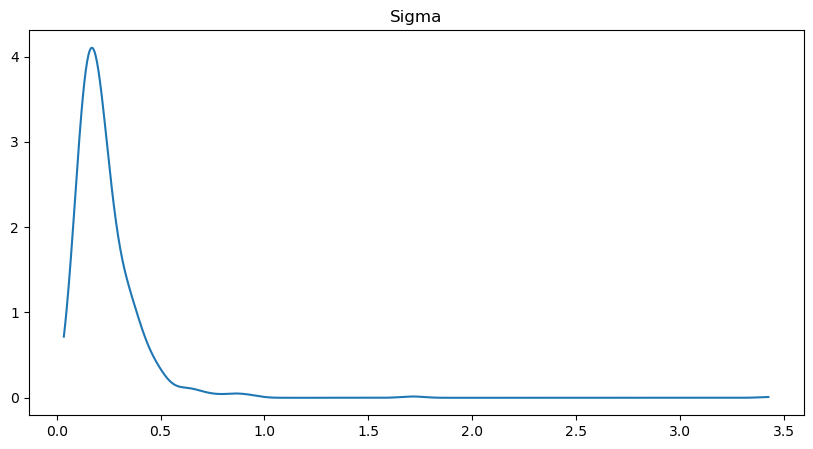

In [8]:
# Get sigma pdf
x, pdf = func.get_sigma_pdf()

# # Plot sigma pdf
plt.clf()
plt.figure(figsize=(10, 5))
plt.plot(x, pdf)
plt.title('Sigma')
plt.show()

In [9]:
# Get baseline sigmas
from params import N_SIGMAS

def get_baseline_sigmas(func: Functions, n_sigmas: int, min_sigma: float = 0.05, max_prob: float = 0.99):
    # Get guaranteed sigma
    guaranteed_sigma = func.get_guaranteed_sigma(max_prob)
   
    # Get sigmas
    sigmas = np.linspace(min_sigma, guaranteed_sigma, n_sigmas)
    return sigmas

baseline_sigmas = get_baseline_sigmas(func, N_SIGMAS)
print(baseline_sigmas)


[0.05       0.16035458 0.27070916 0.38106374 0.49141831 0.60177289
 0.71212747 0.82248205 0.93283663 1.04319121]


<Figure size 640x480 with 0 Axes>

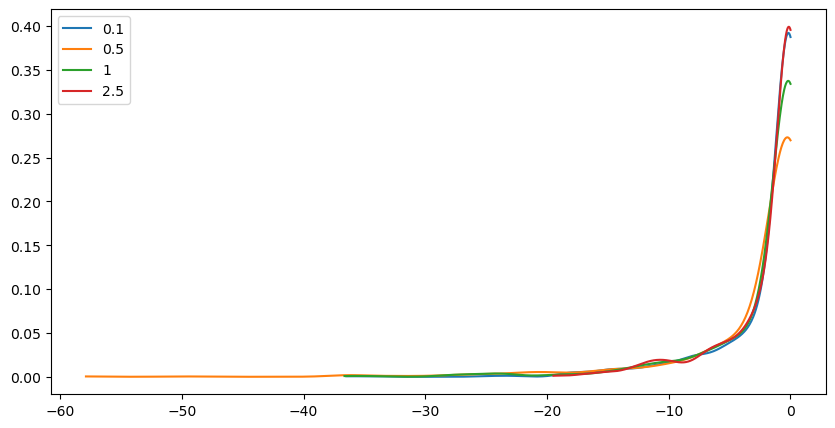

In [10]:
# Get R pdf
plt.clf()
plt.figure(figsize=(10, 5))

for s in [0.1, 0.5, 1, 2.5]:
    R = func.get_R(s)
    plt.plot(R[0], R[1], label=f'{s}')

plt.legend()
plt.show()

In [11]:
# Realized pnl testing
for sigma in [0.1, 0.25, 0.5, 1, 2.5]:
    R = func.get_realized_pnl_mode(sigma)
    print(f'R({sigma}) = {R}')


R(0.1) = -0.21692768562848386
R(0.25) = -0.23351674791935295
R(0.5) = -0.23487308888888947
R(1) = -0.20142460870870593
R(2.5) = -0.13645078943944


<Figure size 640x480 with 0 Axes>

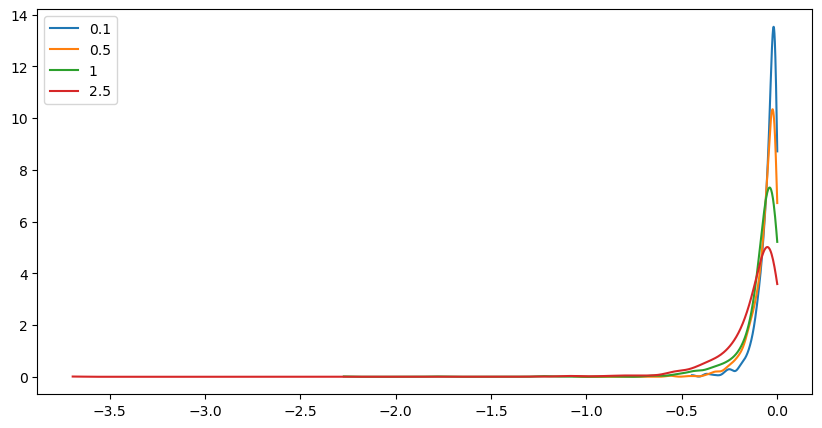

In [12]:
# Get S pdf
plt.clf()
plt.figure(figsize=(10, 5))

for s in [0.1, 0.5, 1, 2.5]:
    S = func.get_S(s)
    plt.plot(S[0], S[1], label=f'{s}')

plt.legend()
plt.show()


<Figure size 640x480 with 0 Axes>

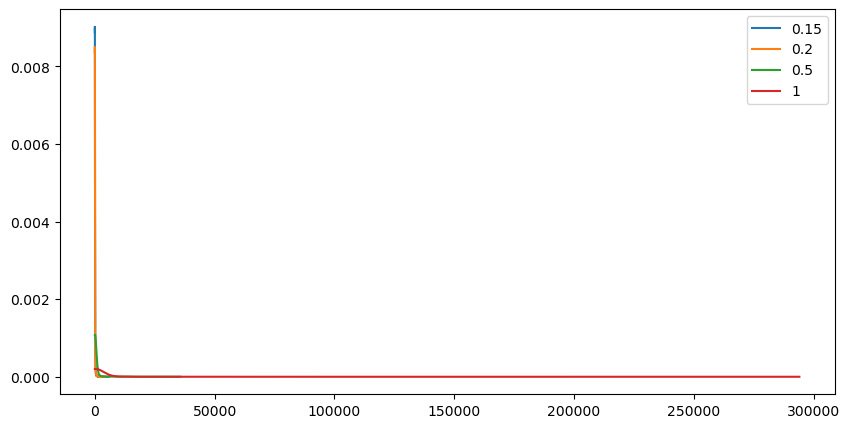

In [13]:
# Get D pdf
plt.clf()
plt.figure(figsize=(10, 5))

for s in [0.15, 0.2, 0.5, 1]:
    D = func.get_D(s)
    plt.plot(D[0], D[1], label=f'{s}')

plt.legend()
plt.show()


In [14]:
# Positions per week testing
for sigma in [0.1, 0.25, 0.5, 1, 2.5]:
    N = func.get_week_pos_count_mode(sigma)
    print(f'N({sigma}) = {N}')

N(0.1) = 9
N(0.25) = 17
N(0.5) = 63
N(1) = 295
N(2.5) = 286


<Figure size 640x480 with 0 Axes>

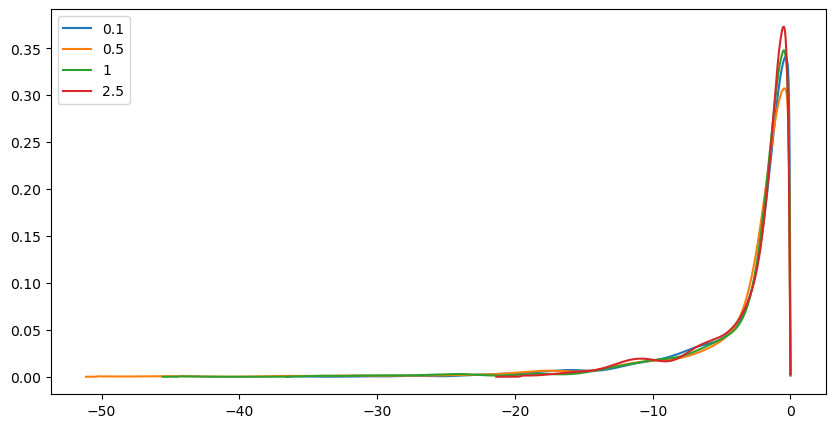

In [15]:
# Get SR pdf
plt.clf()
plt.figure(figsize=(10, 5))

for s in [0.1, 0.5, 1, 2.5]:
    SR = func.get_SR(s)
    plt.plot(SR[0], SR[1], label=f'{s}')

plt.legend()
plt.show()


In [16]:
# Test get_liquidation_probability
for s in [0.1, 0.5, 1, 2.5]:
    for l in [1, 10, 50, 100]:
        p = func.get_liquidation_probability(s, l)
        print(f'p({s}, {l}) = {p:.4f}')


p(0.1, 1) = 0.0000
p(0.1, 10) = 0.0842
p(0.1, 50) = 0.4247
p(0.1, 100) = 0.6665
p(0.5, 1) = 0.0000
p(0.5, 10) = 0.1087
p(0.5, 50) = 0.5191
p(0.5, 100) = 0.7402
p(1, 1) = 0.0000
p(1, 10) = 0.0953
p(1, 50) = 0.4849
p(1, 100) = 0.6842
p(2.5, 1) = 0.0000
p(2.5, 10) = 0.0820
p(2.5, 50) = 0.4476
p(2.5, 100) = 0.6799


In [17]:
def leverage_report_gather_parametrized(test_data):
    # Gather params
    all_params = {}

    for item in test_data:
        total_trades_executed = int(item['stat']['agg']['total_trades_executed'])
        if total_trades_executed == 0:
            continue

        # Parametrization
        test_volume_usd = int(item['run_conf']['test_volume_usd'])
        only_side = int(item['run_conf']['only_side'])
        
        # Metrics
        sigma = float(item['v'])
        pnl = min(0, float(item['stat']['agg']['pnl']) / test_volume_usd * 100.0)
        positions_per_week = (7*24*60*60) / float(item['stat']['agg']['full_execution_time'])

        # Init
        if only_side not in all_params:
            all_params[only_side] = {}
        
        if test_volume_usd not in all_params[only_side]:
            all_params[only_side][test_volume_usd] = {
                'pnl_list': [],
                'positions_per_week_list': [],
                'neutral_excursions_list': [],
            }

        all_params[only_side][test_volume_usd]['pnl_list'].append((sigma, pnl))
        all_params[only_side][test_volume_usd]['positions_per_week_list'].append((sigma, positions_per_week))

        for ne in item['neutral_excursions']:
            all_params[only_side][test_volume_usd]['neutral_excursions_list'].append((sigma, ne))

    # Sort all by sigma
    for only_side in all_params:
        for test_volume_usd in all_params[only_side]:
            all_params[only_side][test_volume_usd]['pnl_list'].sort(key=lambda x: x[0])
            all_params[only_side][test_volume_usd]['positions_per_week_list'].sort(key=lambda x: x[0])
            all_params[only_side][test_volume_usd]['neutral_excursions_list'].sort(key=lambda x: x[0])

    return all_params

In [18]:
# Report method
def get_overall_liquidation_probability(func: Functions, sigma: float, leverage: float):
    # Get liquidation probability
    p = func.get_liquidation_probability(sigma, leverage)

    # Get positions per week
    N = func.get_week_pos_count_mode(sigma)

    # Get concequtive liquidation probability
    return 1 - (1 - p) ** N

def generate_report(func: Functions, sigmas: list, leverages: list, header_fields: dict):
    csv = []

    for score, sigma in enumerate(sigmas):
        for leverage in leverages:
            row = {
                'sigma': sigma,
                'vlt_score': score,
                'leverage': leverage,
                'liquidation_p': get_overall_liquidation_probability(func, sigma, leverage),
            }
            
            row = {**header_fields, **row}
            csv.append(row)

    return csv


In [19]:
# Example report
import pandas as pd
from itables import show
from params import LEVERAGES

df = generate_report(func, baseline_sigmas, LEVERAGES, {'name': 'test'})
df = pd.DataFrame(df)
show(df)


Loading ITables v2.6.2 from the internet... (need help?)


In [20]:
# Generate full report
# Load tests from results folder
import pickle, os
from tqdm import tqdm

def load_tests(symbol, conf):
    folder = f'/_data/base/{symbol}/results/{conf}'
    assert os.path.isdir(folder), f'Results folder not found: {folder}'

    files = [fn for fn in os.listdir(folder) if fn.endswith('.pkl')]
    files.sort()
    assert len(files) > 0, f'No result files in: {folder}'

    sizes_mb = 0.0
    count = 0

    test_data: list = []
    pbar = tqdm(total=len(files), desc=f'Loading tests for {symbol} {conf}')

    for fn in files:
        pbar.update(1)
        path = f'{folder}/{fn}'
        assert os.path.isfile(path), f'Not a file: {path}'
        size_mb = os.path.getsize(path) / 1024 / 1024
        with open(path, 'rb') as f:
            data = pickle.load(f)
        assert isinstance(data, list), f'File is not a list: {path}'
        test_data.extend(data)
        sizes_mb += size_mb
        count += len(data)
    
    pbar.close()

    print(f'Total size: {sizes_mb:.3f} MB')
    print(f'Loaded total: {len(test_data)} tests from {len(files)} files')

    return test_data

In [21]:
# Load confs
import json

def load_confs():
    folder = './run_confs'
    confs = {}

    for file in os.listdir(folder):
        if not file.endswith('.json'):
            continue

        with open(f'{folder}/{file}', 'r') as f:
            conf = json.load(f)
            confs[file.replace('.json', '')] = conf

    return confs

In [22]:
# Generate report
import os, pandas as pd
from itables import show

DIR = '/_data/base'

# List all symbols
symbols = [fn for fn in os.listdir(DIR) if os.path.isdir(f'{DIR}/{fn}')]
symbols.sort()
print(f'Symbols: {symbols}')

csv = []

for symbol in symbols:
    print(f'Building reports for: {symbol}')

    # Load confs
    folder = f'/_data/base/{symbol}/results'
    confs = load_confs()
    print(f'Found {len(confs)} configs')

    for name, conf in confs.items():
        print(f'Building report for: {symbol} {name}')

        # Load tests
        test_data = load_tests(symbol, name)

        # Gather params
        all_params = leverage_report_gather_parametrized(test_data)

        for only_side in all_params:
            for test_volume_usd in all_params[only_side]:
                pnl_list = all_params[only_side][test_volume_usd]['pnl_list']
                positions_per_week_list = all_params[only_side][test_volume_usd]['positions_per_week_list']
                neutral_excursions_list = all_params[only_side][test_volume_usd]['neutral_excursions_list']

                # Initialize functions
                func = Functions(pnl_list, positions_per_week_list, neutral_excursions_list)

                # Get baseline sigmas
                baseline_sigmas = get_baseline_sigmas(func, N_SIGMAS)
                print(f' - baseline sigmas for {symbol} {name} {only_side} {test_volume_usd}: {baseline_sigmas}')

                # Build report
                csv.extend(generate_report(func, baseline_sigmas, LEVERAGES, {
                    'symbol': symbol,
                    'conf': conf['description'],
                    'only_side': only_side,
                    'test_volume_usd': test_volume_usd,
                }))

# Convert to DataFrame
df = pd.DataFrame(csv)

# Show
show(df)

# Save
os.makedirs('reports', exist_ok=True)
df.to_csv('reports/leverage_report.csv', index=False)


Symbols: ['BTCUSDC', 'ETHUSDC', 'SOLUSDC']
Building reports for: BTCUSDC
Found 4 configs
Building report for: BTCUSDC list_01p


Loading tests for BTCUSDC list_01p: 100%|██████████| 100/100 [00:23<00:00,  4.33it/s]


Total size: 921.409 MB
Loaded total: 974993 tests from 100 files
 - baseline sigmas for BTCUSDC list_01p 0 50000: [0.05       0.12022058 0.19044116 0.26066174 0.33088232 0.4011029
 0.47132348 0.54154406 0.61176464 0.68198522]
 - baseline sigmas for BTCUSDC list_01p 0 10000: [0.05       0.12025365 0.1905073  0.26076095 0.33101461 0.40126826
 0.47152191 0.54177556 0.61202921 0.68228286]
 - baseline sigmas for BTCUSDC list_01p 0 70000: [0.05       0.11667133 0.18334266 0.250014   0.31668533 0.38335666
 0.45002799 0.51669932 0.58337065 0.65004199]
 - baseline sigmas for BTCUSDC list_01p 0 60000: [0.05       0.12131976 0.19263953 0.26395929 0.33527906 0.40659882
 0.47791859 0.54923835 0.62055812 0.69187788]
 - baseline sigmas for BTCUSDC list_01p 0 40000: [0.05       0.10690119 0.16380237 0.22070356 0.27760474 0.33450593
 0.39140711 0.4483083  0.50520948 0.56211067]
 - baseline sigmas for BTCUSDC list_01p 0 80000: [0.05       0.12225798 0.19451596 0.26677395 0.33903193 0.41128991
 0.4835478

Loading tests for BTCUSDC list_01p_s: 100%|██████████| 100/100 [00:15<00:00,  6.50it/s]


Total size: 267.403 MB
Loaded total: 999917 tests from 100 files
 - baseline sigmas for BTCUSDC list_01p_s -1 50000: [0.05       0.12277416 0.19554832 0.26832248 0.34109664 0.4138708
 0.48664496 0.55941912 0.63219328 0.70496744]
 - baseline sigmas for BTCUSDC list_01p_s -1 90000: [0.05       0.13000418 0.21000835 0.29001253 0.3700167  0.45002088
 0.53002505 0.61002923 0.6900334  0.77003758]
 - baseline sigmas for BTCUSDC list_01p_s -1 70000: [0.05       0.10185569 0.15371138 0.20556706 0.25742275 0.30927844
 0.36113413 0.41298982 0.4648455  0.51670119]
 - baseline sigmas for BTCUSDC list_01p_s -1 40000: [0.05       0.10653649 0.16307297 0.21960946 0.27614594 0.33268243
 0.38921891 0.4457554  0.50229188 0.55882837]
 - baseline sigmas for BTCUSDC list_01p_s -1 60000: [0.05       0.10544436 0.16088871 0.21633307 0.27177742 0.32722178
 0.38266613 0.43811049 0.49355484 0.5489992 ]
 - baseline sigmas for BTCUSDC list_01p_s -1 20000: [0.05       0.11195678 0.17391356 0.23587033 0.29782711 0.3

...

Loading tests for SOLUSDC list_1u_s: 100%|██████████| 100/100 [00:13<00:00,  7.69it/s]


Total size: 263.554 MB
Loaded total: 999758 tests from 100 files
 - baseline sigmas for SOLUSDC list_1u_s 1 90000: [0.05       0.20577111 0.36154222 0.51731333 0.67308444 0.82885555
 0.98462666 1.14039776 1.29616887 1.45193998]
 - baseline sigmas for SOLUSDC list_1u_s 1 60000: [0.05       0.16897786 0.28795572 0.40693358 0.52591144 0.6448893
 0.76386716 0.88284502 1.00182288 1.12080074]
 - baseline sigmas for SOLUSDC list_1u_s 1 30000: [0.05       0.15537792 0.26075583 0.36613375 0.47151167 0.57688959
 0.6822675  0.78764542 0.89302334 0.99840125]
 - baseline sigmas for SOLUSDC list_1u_s 1 50000: [0.05       0.15637283 0.26274565 0.36911848 0.47549131 0.58186413
 0.68823696 0.79460979 0.90098261 1.00735544]
 - baseline sigmas for SOLUSDC list_1u_s 1 40000: [0.05       0.1794187  0.30883739 0.43825609 0.56767479 0.69709348
 0.82651218 0.95593088 1.08534957 1.21476827]
 - baseline sigmas for SOLUSDC list_1u_s 1 20000: [0.05       0.22102792 0.39205583 0.56308375 0.73411166 0.90513958
 1.0

Loading tests for SOLUSDC list_1u: 100%|██████████| 100/100 [00:18<00:00,  5.49it/s]


Total size: 563.128 MB
Loaded total: 995988 tests from 100 files
 - baseline sigmas for SOLUSDC list_1u 0 70000: [0.05       0.19344806 0.33689613 0.48034419 0.62379226 0.76724032
 0.91068839 1.05413645 1.19758451 1.34103258]
 - baseline sigmas for SOLUSDC list_1u 0 40000: [0.05       0.15025779 0.25051557 0.35077336 0.45103114 0.55128893
 0.65154671 0.7518045  0.85206228 0.95232007]
 - baseline sigmas for SOLUSDC list_1u 0 20000: [0.05       0.14891019 0.24782038 0.34673057 0.44564076 0.54455095
 0.64346114 0.74237132 0.84128151 0.9401917 ]
 - baseline sigmas for SOLUSDC list_1u 0 90000: [0.05       0.18118021 0.31236042 0.44354063 0.57472084 0.70590105
 0.83708126 0.96826147 1.09944168 1.23062189]
 - baseline sigmas for SOLUSDC list_1u 0 60000: [0.05       0.20029232 0.35058465 0.50087697 0.6511693  0.80146162
 0.95175395 1.10204627 1.2523386  1.40263092]
 - baseline sigmas for SOLUSDC list_1u 0 80000: [0.05       0.16203578 0.27407157 0.38610735 0.49814313 0.61017892
 0.7222147  0.8

Loading ITables v2.6.2 from the internet... (need help?)
